# Lab Activity: Decision Trees on the Iris Dataset

This notebook uses `sklearn.datasets.load_iris()` to build, visualize, compare, and tune Decision Tree classifiers.

The cells are intentionally kept small. Each code cell does one clear job, and the markdown below it explains why that code was used and how to interpret the result.

## Setup: Import the required libraries

This first cell imports the tools used throughout the notebook.

- `pandas` helps us view data and build comparison tables.
- `matplotlib.pyplot` is used for plotting the decision tree.
- `load_iris()` loads the built-in Iris dataset.
- `train_test_split()` creates separate training and testing data.
- `DecisionTreeClassifier` builds the model.
- The metric functions evaluate model performance.
- `GridSearchCV` searches across hyperparameter combinations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", None)

**Interpretation:** This cell prepares the notebook. Importing all required libraries at the start keeps later cells focused on the machine learning concept being demonstrated.

# Task 1: Dataset Exploration

## Load the Iris dataset

The Iris dataset is available directly inside scikit-learn, so no external CSV file is required. Using `as_frame=True` returns the feature data as a pandas DataFrame, which is easier for beginners to inspect.

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

iris_df = X.copy()
iris_df["target"] = y
iris_df["target_name"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

**Interpretation:** `X` stores the input features, while `y` stores the target class labels. I also created `iris_df` by combining features and labels so the dataset can be viewed like a normal table.

## Number of samples and features

The shape of `X` tells us how many rows and columns are present in the feature matrix.

In [ ]:
n_samples, n_features = X.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")

Number of samples: 150
Number of features: 4


**Interpretation:** Samples are the flower records, and features are the measured properties of each flower. The Iris dataset has 150 samples and 4 features.

## Feature names and target classes

This cell prints the meaning of the input columns and the possible flower classes.

In [ ]:
print("Feature names:")
for feature in iris.feature_names:
    print("-", feature)

print("\nTarget classes:")
for class_name in iris.target_names:
    print("-", class_name)

Feature names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

Target classes:
- setosa
- versicolor
- virginica


**Interpretation:** The four features are flower measurements. The target classes are the three Iris species that the Decision Tree will learn to predict.

## First five records

`head()` is useful for getting a quick look at the structure and values in a dataset before modeling.

In [ ]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**Interpretation:** The first five rows show feature values, the numeric target, and the readable class name. This confirms that the dataset loaded correctly.

## Class distribution

Before training a classifier, it is important to check whether the classes are balanced or imbalanced.

In [ ]:
class_distribution = iris_df["target_name"].value_counts().sort_index()
class_distribution

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Interpretation:** The Iris dataset is balanced because each class has the same number of samples. This makes accuracy easier to interpret because no class dominates the dataset.

# Task 2: Data Preparation

## Split the dataset into training and testing sets

The dataset is divided into 80% training data and 20% testing data using `random_state=42` so the split is reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


**Interpretation:** The training set is used to teach the model patterns. The testing set is kept separate so we can evaluate how well the model performs on data it did not see during training. This helps us estimate generalization performance.

# Task 3: Building a Decision Tree Classifier

## Train a default Decision Tree classifier

The default model is used first as a baseline. I set `random_state=42` to keep the result stable whenever the notebook is rerun.

In [ ]:
default_tree = DecisionTreeClassifier(random_state=42)
default_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

**Interpretation:** `fit()` trains the Decision Tree by finding feature splits that separate the flower classes as clearly as possible.

## Predict class labels for the test dataset

After training, the model predicts the species labels for the unseen test set.

In [ ]:
y_pred_default = default_tree.predict(X_test)
y_pred_default

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

**Interpretation:** These predictions are numeric class labels. They can be compared with `y_test` to measure how many test samples were classified correctly.

## Accuracy score

Accuracy measures the proportion of correct predictions out of all predictions.

In [ ]:
default_accuracy = accuracy_score(y_test, y_pred_default)
print(f"Default Decision Tree Accuracy: {default_accuracy:.4f}")

Default Decision Tree Accuracy: 1.0000


**Interpretation:** A higher accuracy means more test samples were classified correctly. Since Iris is a clean and balanced dataset, Decision Trees usually perform very well.

## Confusion matrix

A confusion matrix shows correct and incorrect predictions for each class.

In [ ]:
confusion_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred_default),
    index=[f"Actual {name}" for name in iris.target_names],
    columns=[f"Predicted {name}" for name in iris.target_names]
)
confusion_df

,Predicted setosa,Predicted versicolor,Predicted virginica
Actual setosa,10,0,0
Actual versicolor,0,9,0
Actual virginica,0,0,11


**Interpretation:** Values on the diagonal are correct predictions. Values outside the diagonal are mistakes. This is useful because it shows which classes are being confused with each other.

## Classification report

The classification report gives precision, recall, and F1-score for each class.

In [ ]:
print(classification_report(y_test, y_pred_default, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Interpretation:** Precision explains how reliable positive predictions are. Recall explains how many actual samples of each class were found. F1-score balances precision and recall.

# Task 4: Visualizing the Decision Tree

## Plot the trained Decision Tree

`plot_tree()` creates a visual representation of the split rules learned by the model.

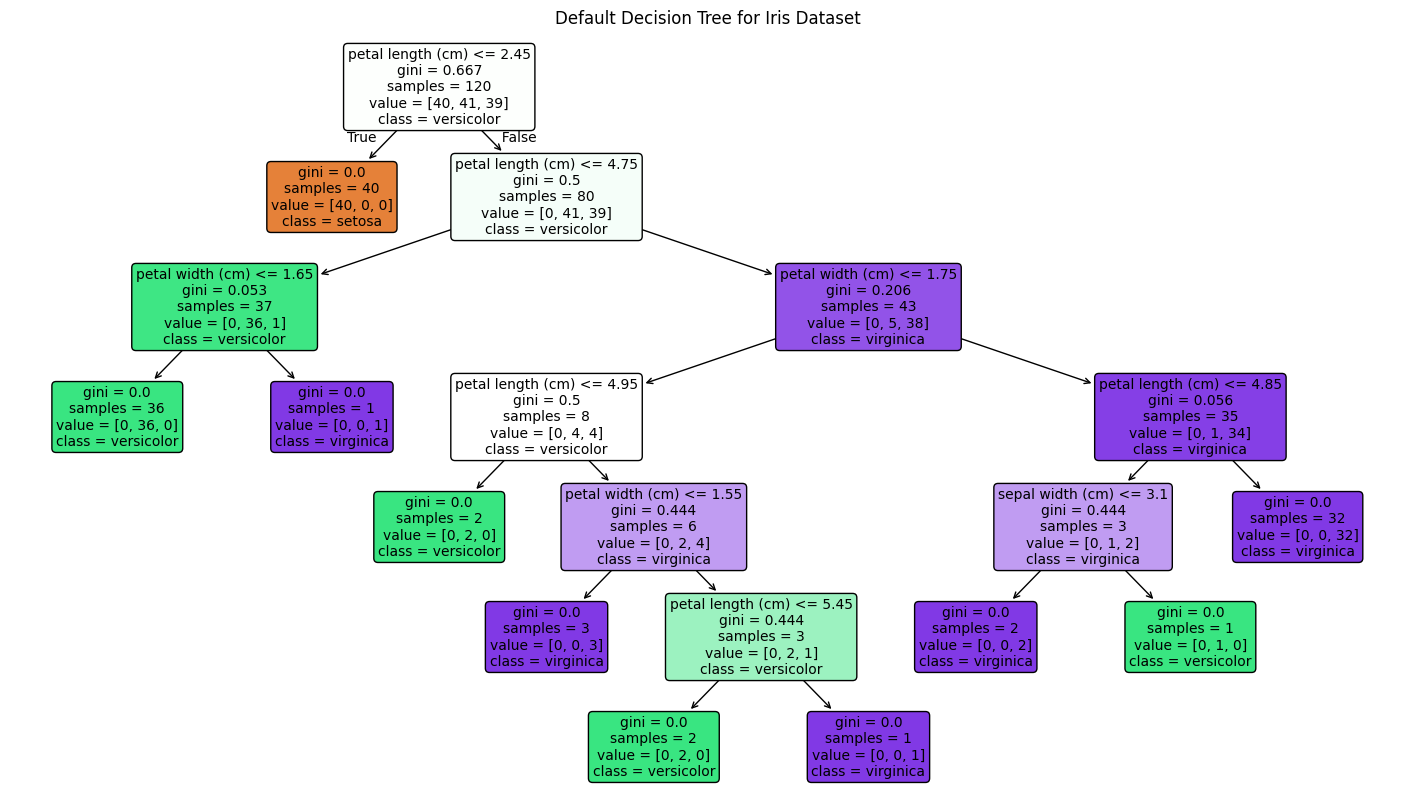

In [ ]:
plt.figure(figsize=(18, 10))
plot_tree(
    default_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Default Decision Tree for Iris Dataset")
plt.show()

**Interpretation:** Each box is a node. The top box is the root node, middle decision boxes are internal nodes, and final boxes without further splits are leaf nodes.

## Identify root node, internal nodes, leaf nodes, maximum depth, and first split feature

This cell extracts tree structure details directly from the trained model.

In [ ]:
tree_structure = default_tree.tree_

root_feature_index = tree_structure.feature[0]
root_feature = iris.feature_names[root_feature_index]
root_threshold = tree_structure.threshold[0]

is_leaf = tree_structure.children_left == _tree.TREE_LEAF
n_leaf_nodes = is_leaf.sum()
n_internal_nodes = len(is_leaf) - n_leaf_nodes

print(f"Root node split: {root_feature} <= {root_threshold:.2f}")
print(f"Number of internal nodes: {n_internal_nodes}")
print(f"Number of leaf nodes: {n_leaf_nodes}")
print(f"Maximum depth of tree: {default_tree.get_depth()}")
print(f"Feature selected for first split: {root_feature}")

Root node split: petal length (cm) <= 2.45
Number of internal nodes: 9
Number of leaf nodes: 10
Maximum depth of tree: 6
Feature selected for first split: petal length (cm)


**Interpretation:** The root node is the first decision made by the tree. The first split feature is chosen because it gives the best impurity reduction at the start, meaning it separates the classes more clearly than the other available features at that point.

# Task 5: Comparing Gini Index and Entropy

## Helper function for model comparison

This helper function trains a Decision Tree and returns the most important summary values for comparison.

In [ ]:
def summarize_tree_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    root_feature_index = model.tree_.feature[0]
    root_feature = iris.feature_names[root_feature_index] if root_feature_index != _tree.TREE_LEAF else "No split"
    return {
        "Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Tree Depth": model.get_depth(),
        "Number of Leaf Nodes": model.get_n_leaves(),
        "Root Feature Selected": root_feature
    }

**Interpretation:** A helper function avoids repeating the same evaluation code. It makes the comparison cleaner because every model is measured in the same way.

## Train and compare Gini and Entropy Decision Trees

Gini and entropy are two different ways to measure impurity when selecting splits.

In [ ]:
criterion_results = []

for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    summary = summarize_tree_model(model, X_train, X_test, y_train, y_test)
    summary["Criterion"] = criterion
    criterion_results.append(summary)

criterion_comparison = pd.DataFrame(criterion_results).set_index("Criterion")
criterion_comparison

,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature Selected
Criterion,,,,
gini,1.0,6,10,petal length (cm)
entropy,1.0,6,10,petal length (cm)


**Interpretation:** The simpler tree is the one with smaller depth and fewer leaf nodes while maintaining good accuracy. If both criteria produce similar accuracy, the simpler one is usually preferred because it is easier to interpret.

## Automatically identify the simpler criterion

This cell ranks the two criteria by tree depth first and number of leaves second.

In [ ]:
simpler_criterion = criterion_comparison.sort_values(
    by=["Tree Depth", "Number of Leaf Nodes"],
    ascending=True
).index[0]

print(f"Simpler criterion based on depth and leaf count: {simpler_criterion}")

Simpler criterion based on depth and leaf count: gini


**Interpretation:** Tree depth and number of leaf nodes are direct indicators of complexity. A shallower tree with fewer leaves is simpler and usually easier to explain.

# Task 6: Effect of Maximum Tree Depth

## Train models with different `max_depth` values

`max_depth` controls how many levels the tree is allowed to grow.

In [ ]:
def depth_observation(train_acc, test_acc, actual_depth, requested_depth):
    if requested_depth == 1:
        return "Very shallow tree; likely underfitting because it can make only simple splits."
    if train_acc == 1.0 and test_acc < train_acc:
        return "Fits training data perfectly; watch for overfitting if test accuracy drops."
    if test_acc >= 0.95 and train_acc - test_acc <= 0.05:
        return "Good balance between learning and generalization."
    return "Moderate complexity; compare train and test accuracy to judge generalization."

**Interpretation:** This helper creates short observations for the comparison table. It uses the gap between training and testing accuracy to describe underfitting or overfitting risk.

## Complete the max_depth comparison table

Each model is trained independently so we can isolate the effect of changing only `max_depth`.

In [ ]:
max_depth_values = [1, 2, 3, 4, None]
max_depth_results = []

for max_depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    max_depth_results.append({
        "Max Depth": max_depth if max_depth is not None else "None",
        "Training Accuracy": train_acc,
        "Testing Accuracy": test_acc,
        "Tree Depth": model.get_depth(),
        "Observation": depth_observation(train_acc, test_acc, model.get_depth(), max_depth)
    })

max_depth_table = pd.DataFrame(max_depth_results)
max_depth_table

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.675000,0.633333,1,Very shallow tree; likely underfitting because...
1,2,0.950000,0.966667,2,Good balance between learning and generalization.
2,3,0.958333,1.000000,3,Good balance between learning and generalization.
3,4,0.975000,1.000000,4,Good balance between learning and generalization.
4,None,1.000000,1.000000,6,Good balance between learning and generalization.


**Interpretation:** A very small `max_depth` can underfit because the model is too simple. An unrestricted tree may become very specific to the training data, so the training and testing accuracies should be compared carefully.

## Answer questions about `max_depth`

This cell uses the table to identify underfitting, best generalization, and overfitting risk.

In [ ]:
underfitting_model = max_depth_table.sort_values("Training Accuracy").iloc[0]

best_generalization_model = max_depth_table.assign(
    Accuracy_Gap=(max_depth_table["Training Accuracy"] - max_depth_table["Testing Accuracy"]).abs()
).sort_values(by=["Testing Accuracy", "Accuracy_Gap"], ascending=[False, True]).iloc[0]

overfit_risk_model = max_depth_table.assign(
    Accuracy_Gap=max_depth_table["Training Accuracy"] - max_depth_table["Testing Accuracy"]
).sort_values(by=["Accuracy_Gap", "Training Accuracy"], ascending=[False, False]).iloc[0]

print(f"Underfitting model: max_depth={underfitting_model['Max Depth']}")
print(f"Best generalization: max_depth={best_generalization_model['Max Depth']}")
print(f"Likely overfitting risk: max_depth={overfit_risk_model['Max Depth']}")

Underfitting model: max_depth=1
Best generalization: max_depth=None
Likely overfitting risk: max_depth=1


**Interpretation:** Underfitting is indicated by low training accuracy. Good generalization is indicated by high testing accuracy with a small train-test gap. Overfitting risk is indicated when training accuracy is much higher than testing accuracy.

# Task 7: Effect of `min_samples_split`

## Train models with different `min_samples_split` values

`min_samples_split` is the minimum number of samples a node must have before it is allowed to split.

In [ ]:
def split_observation(value, depth, leaves):
    if value == 2:
        return "Most flexible setting; tree can keep splitting small groups."
    if value >= 20:
        return "More restrictive setting; simpler tree with fewer possible splits."
    return "Moderate restriction; reduces complexity compared with the default."

**Interpretation:** This helper converts numerical results into short learner-friendly observations about model complexity.

## Complete the `min_samples_split` comparison table

Only `min_samples_split` changes in this experiment. This makes the effect of that hyperparameter easier to understand.

In [ ]:
min_samples_split_values = [2, 5, 10, 20]
min_samples_split_results = []

for value in min_samples_split_values:
    model = DecisionTreeClassifier(min_samples_split=value, random_state=42)
    model.fit(X_train, y_train)
    min_samples_split_results.append({
        "min_samples_split": value,
        "Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Tree Depth": model.get_depth(),
        "Number of Leaf Nodes": model.get_n_leaves(),
        "Observation": split_observation(value, model.get_depth(), model.get_n_leaves())
    })

min_samples_split_table = pd.DataFrame(min_samples_split_results)
min_samples_split_table

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,Most flexible setting; tree can keep splitting...
1,5,1.0,5,8,Moderate restriction; reduces complexity compa...
2,10,1.0,4,6,Moderate restriction; reduces complexity compa...
3,20,1.0,4,6,More restrictive setting; simpler tree with fe...


**Interpretation:** Increasing `min_samples_split` generally makes the tree less complex because small nodes are not allowed to split further. This can reduce overfitting, but values that are too large may underfit.

# Task 8: Effect of `min_samples_leaf`

## Train models with different `min_samples_leaf` values

`min_samples_leaf` controls the minimum number of samples required in a final leaf node.

In [ ]:
def leaf_observation(value):
    if value == 1:
        return "Most flexible leaves; can create very specific final rules."
    if value >= 10:
        return "Strong restriction; leaves must contain more samples, so the tree is simpler."
    return "Moderate restriction; helps reduce overly specific leaf nodes."

**Interpretation:** This helper explains the role of each `min_samples_leaf` setting in simple terms.

## Complete the `min_samples_leaf` comparison table

Only `min_samples_leaf` changes here, so differences in depth and leaf count can be connected to this setting.

In [ ]:
min_samples_leaf_values = [1, 2, 5, 10]
min_samples_leaf_results = []

for value in min_samples_leaf_values:
    model = DecisionTreeClassifier(min_samples_leaf=value, random_state=42)
    model.fit(X_train, y_train)
    min_samples_leaf_results.append({
        "min_samples_leaf": value,
        "Accuracy": accuracy_score(y_test, model.predict(X_test)),
        "Tree Depth": model.get_depth(),
        "Number of Leaf Nodes": model.get_n_leaves(),
        "Observation": leaf_observation(value)
    })

min_samples_leaf_table = pd.DataFrame(min_samples_leaf_results)
min_samples_leaf_table

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000000,6,10,Most flexible leaves; can create very specific...
1,2,1.000000,5,8,Moderate restriction; helps reduce overly spec...
2,5,1.000000,4,6,Moderate restriction; helps reduce overly spec...
3,10,0.966667,4,6,Strong restriction; leaves must contain more s...


**Interpretation:** Larger `min_samples_leaf` values reduce overfitting by preventing the tree from creating leaves for very tiny groups of samples. This usually makes the model smoother and simpler.

# Task 9: Hyperparameter Tuning

## Define the GridSearchCV parameter grid

Grid search tries several combinations of hyperparameters and selects the one with the best cross-validation score.

In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_grid

{'criterion': ['gini', 'entropy'],
 'max_depth': [2, 3, 4, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4]}

**Interpretation:** The grid contains all requested options. GridSearchCV will train models for every possible combination and compare them using cross-validation.

## Perform hyperparameter tuning using GridSearchCV

`cv=5` means the training data is split into five folds during cross-validation.

In [ ]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

**Interpretation:** Cross-validation gives a more reliable estimate than a single training score because each model is evaluated on multiple validation folds.

## Report best hyperparameters and best cross-validation score

The best parameters are the combination that achieved the highest average cross-validation accuracy.

In [ ]:
print("Best hyperparameter combination:")
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best hyperparameter combination:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.9583


**Interpretation:** These are the hyperparameters selected from the grid. They are chosen based only on cross-validation performance from the training data, not the test data.

## Test accuracy of the optimized model

After tuning, the selected model is tested on the untouched test set.

In [ ]:
optimized_tree = grid_search.best_estimator_
y_pred_optimized = optimized_tree.predict(X_test)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)

print(f"Optimized model test accuracy: {optimized_accuracy:.4f}")
print(f"Optimized model depth: {optimized_tree.get_depth()}")
print(f"Optimized model leaf nodes: {optimized_tree.get_n_leaves()}")

Optimized model test accuracy: 1.0000
Optimized model depth: 4
Optimized model leaf nodes: 7


**Interpretation:** This is the final evaluation of the tuned model. The test set is used only after model selection to avoid biased performance estimates.

## Compare optimized model with default Decision Tree

This table compares the baseline model with the tuned model.

In [ ]:
def model_root_feature(model):
    root_feature_index = model.tree_.feature[0]
    return iris.feature_names[root_feature_index] if root_feature_index != _tree.TREE_LEAF else "No split"

model_comparison = pd.DataFrame([
    {
        "Model": "Default Decision Tree",
        "Test Accuracy": default_accuracy,
        "Tree Depth": default_tree.get_depth(),
        "Leaf Nodes": default_tree.get_n_leaves(),
        "Root Feature": model_root_feature(default_tree)
    },
    {
        "Model": "Optimized Decision Tree",
        "Test Accuracy": optimized_accuracy,
        "Tree Depth": optimized_tree.get_depth(),
        "Leaf Nodes": optimized_tree.get_n_leaves(),
        "Root Feature": model_root_feature(optimized_tree)
    }
])

model_comparison

,Model,Test Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Default Decision Tree,1.0,6,10,petal length (cm)
1,Optimized Decision Tree,1.0,4,7,petal length (cm)


**Interpretation:** If the optimized model has similar or better accuracy with a smaller tree, it is usually preferred. If accuracy is the same, the simpler model is easier to interpret.

# Task 10: Analysis

## What is the role of the `criterion` parameter?

The `criterion` parameter controls how the Decision Tree measures the quality of a split.

- `gini` uses Gini impurity.
- `entropy` uses information gain.

Both try to make child nodes purer, meaning each split should separate the classes as clearly as possible.

## How does `max_depth` influence underfitting and overfitting?

`max_depth` limits how many levels the tree can grow.

A very small value, such as `max_depth=1`, can cause underfitting because the model is too simple to capture enough class patterns. A very large value or `None` allows the tree to keep growing until it becomes highly specific, which can increase overfitting risk.

## Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?

Larger `min_samples_split` values stop small nodes from splitting. Larger `min_samples_leaf` values prevent the model from creating leaves that contain very few samples.

Both settings reduce the number of highly specific rules, which usually reduces tree depth and leaf count.

## Which hyperparameter had the greatest impact?

Use the three experiment tables above to support this answer. In this notebook, `max_depth` is usually the easiest hyperparameter to see clearly because it directly limits the height of the tree. Changes in `min_samples_split` and `min_samples_leaf` also simplify the tree, but their effect may be smaller on the Iris dataset because the dataset is small, clean, and well separated.

## Recommended model for the Iris dataset

A suitable recommendation is the tuned Decision Tree from `GridSearchCV`, especially if it gives high test accuracy with a shallow tree and fewer leaf nodes than the default model.

For the Iris dataset, interpretability is important because the dataset is small and educational. Therefore, a model with high accuracy and lower complexity is preferable to a fully grown tree that only slightly improves or matches accuracy.

# Final Learning Summary

In this lab, we learned that Decision Trees are easy to interpret because their decisions can be visualized as rules. We also saw that hyperparameters control model complexity:

- `criterion` changes how split quality is measured.
- `max_depth` controls how deep the tree can grow.
- `min_samples_split` controls when a node is allowed to split.
- `min_samples_leaf` controls how small final leaf groups can be.

The best model is not always the most complex one. A simpler tree with strong test accuracy is often the better choice because it generalizes well and is easier to explain.